## Importing all the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Displaying the dataset
df = pd.read_csv("../dataset/india_housing_prices.csv",index_col="ID")
df.tail()

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
ID,,,,,,,,,,,,,,,,,,,,,
249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,274.75,0.14,1995,Furnished,...,30,8,6,Low,No,No,"Playground, Garden, Gym, Clubhouse, Pool",East,Broker,Under_Construction
249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,13.40,0.01,2013,Semi-furnished,...,12,8,10,Low,No,No,Playground,South,Broker,Ready_to_Move
249998,Telangana,Warangal,Locality_225,Villa,4,2910,236.94,0.08,2003,Furnished,...,22,10,4,High,Yes,Yes,Playground,South,Builder,Under_Construction
249999,Odisha,Cuttack,Locality_138,Villa,1,1149,141.66,0.12,2007,Unfurnished,...,18,3,7,Low,Yes,Yes,"Playground, Gym, Pool",South,Owner,Ready_to_Move
250000,Haryana,Gurgaon,Locality_268,Independent House,3,4313,199.69,0.05,1990,Semi-furnished,...,35,10,6,Medium,No,No,"Gym, Garden",South,Owner,Under_Construction


## Numerical Columns
**Target Column** - Price_per_SqFt  
**Numerical Columns**  
*(int64)*
1. ID              : Should be removed
2. BHK             : Data ranges from 1 - 5 all having median price similar
3. Size_in_SqFt    : Debatable
4. Year_Built      : Can be removed as we already have age of property
5. Floor_No        : issue
6. Total_Floors    : issue
7. Age_of_Property : Range from 2 - 35 whole numbers
8. Nearby_Schools  : Data range from 1 - 10
9. Nearby_Hospitals: Data range from 1 - 10

*(float64)*
1. Price_in_Lakhs  : Target Column
2. Price_in_SqFt   : Can be removed as we already have price_in_Lakhs

In [3]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
numerical_cols

Index(['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools',
       'Nearby_Hospitals'],
      dtype='str')

In [4]:
## Dropping Price_per_Sqft, Year_Built, Total_Floors
df_transformed= df.drop(columns=["Price_per_SqFt","Year_Built","Total_Floors"])

In [5]:
df_transformed.select_dtypes(include=["int64","float64"]).columns

Index(['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Floor_No', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals'],
      dtype='str')

In [6]:
numerical_cols = df_transformed.select_dtypes(include=["int64", "float64"]).columns

In [7]:
#Manual way to find outliers
for col in numerical_cols:
    Q1 = df_transformed[col].quantile(0.25)
    Q3 = df_transformed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR

    count = ((df_transformed[col] < lower) | (df_transformed[col] > upper)).sum()

    print(f"{col}: {count} outliers")

BHK: 0 outliers
Size_in_SqFt: 0 outliers
Price_in_Lakhs: 0 outliers
Floor_No: 0 outliers
Age_of_Property: 0 outliers
Nearby_Schools: 0 outliers
Nearby_Hospitals: 0 outliers


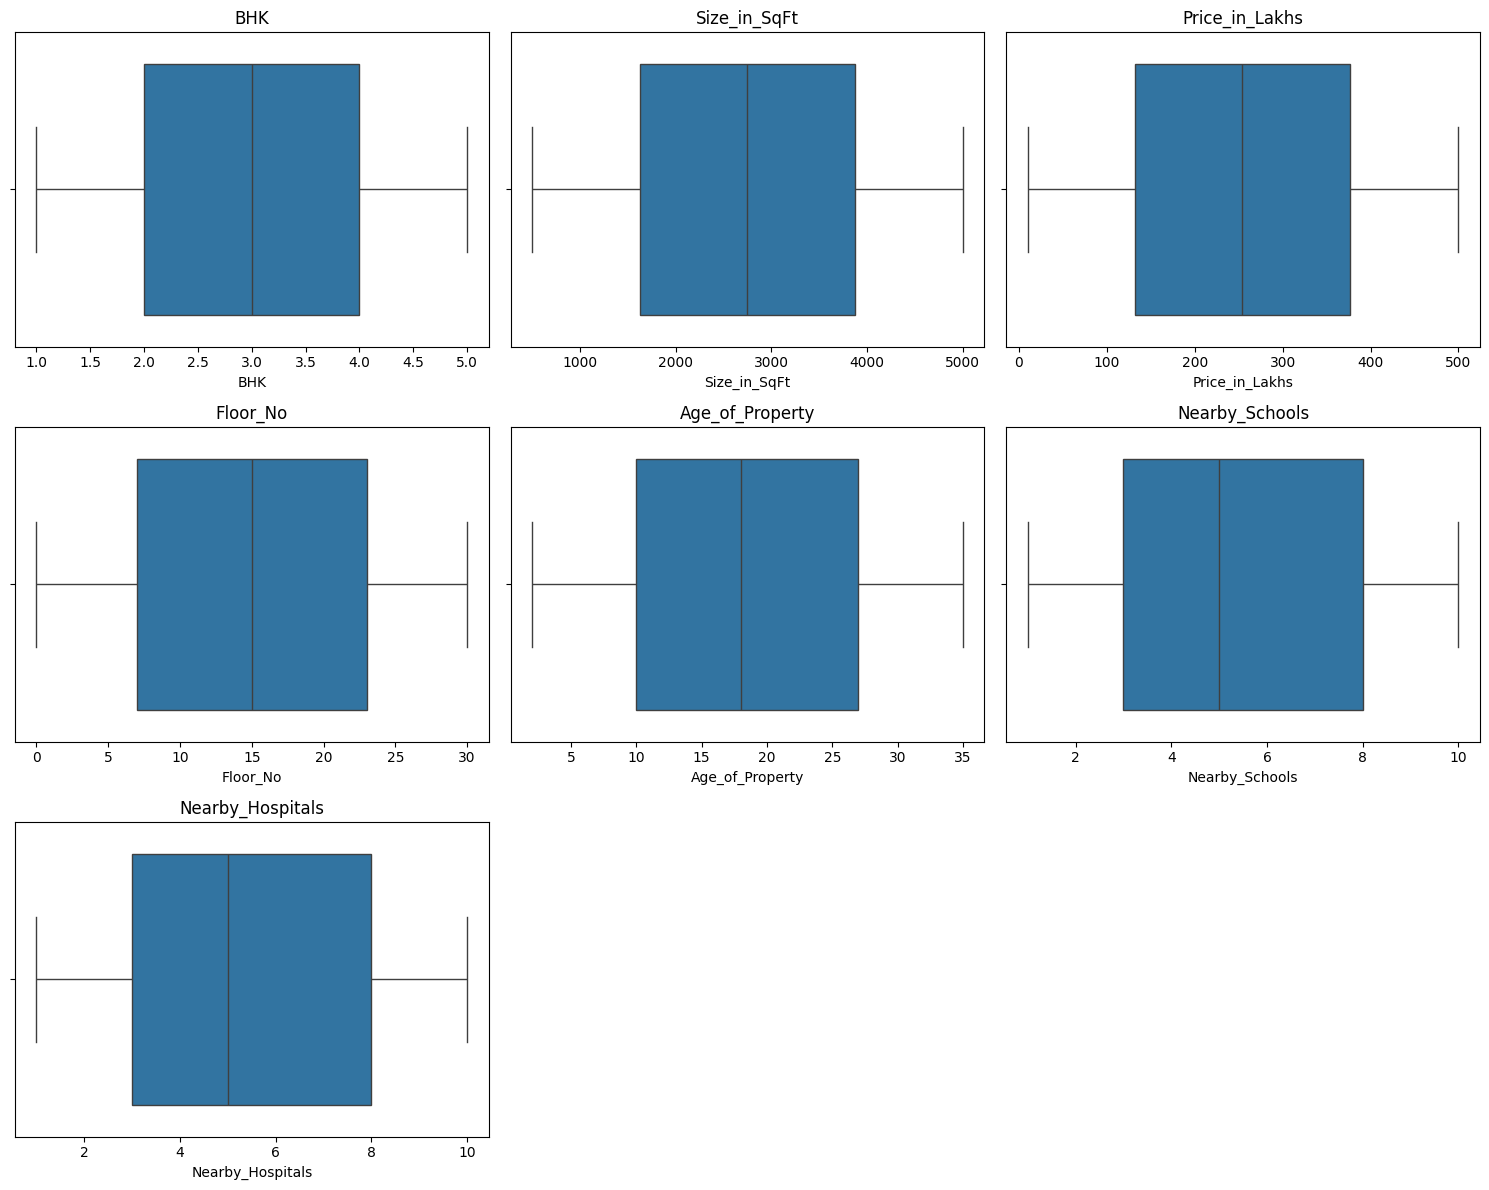

In [8]:
# Box-Plot representation:
import math
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Note** - No outliers exists in the numerical columns

## Categorical Columns

**Categorical Columns**
1. State                              : 20 different states (Target encoding)
2. City                               : 42 different cities (Target encoding)
3. Locality                           : high cardinality (500), one hot, ordinal encoding not much effective (frequency encoding) 
4. Property_Type                      : (3 types) (one-hot encoding)
5. Furnished_Status                   : (3 types) hiarchical (ordinal encoding)
6. Public_Transport_Accessibility     : (3 types) hiarchical (ordinal encoding)
7.  Parking_Space                     : Yes/No (binary)
8.  Security                          : Yes/No (binary)
9.  Amenities                         : can be changed to numerical [5 amenities]
10.  Facing                           : 4 directions (ordinal encoding)
11.  Owner_Type                       : Broker builder owner can be dropped
12.  Availability_Status              : under construction ,ready (ordinal encoding)

In [9]:
# Importing Libraries
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import TargetEncoder
#from sklearn.preprocessing import 

In [10]:
categorical_cols = df_transformed.select_dtypes(include=["str"]).columns

In [11]:
categorical_cols

Index(['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status',
       'Public_Transport_Accessibility', 'Parking_Space', 'Security',
       'Amenities', 'Facing', 'Owner_Type', 'Availability_Status'],
      dtype='str')

In [12]:
# Making List of columns for each transformation
target_cols = ["State","City"]
freq_cols = ["Locality"]
ohe_cols = ["Property_Type","Owner_Type","Facing"]
ordinal_cols = ["Furnished_Status","Public_Transport_Accessibility","Availability_Status","Parking_Space","Security"]
Binary_cols = []

In [13]:
#ONE HOT ENCODING
one_hot = OneHotEncoder(handle_unknown="ignore",sparse_output=False).set_output(transform="pandas")

In [14]:
df_transformed_ohe = one_hot.fit_transform(df_transformed[ohe_cols])

In [15]:
df_transformed_ohe.head()

,Property_Type_Apartment,Property_Type_Independent House,Property_Type_Villa,Owner_Type_Broker,Owner_Type_Builder,Owner_Type_Owner,Facing_East,Facing_North,Facing_South,Facing_West
ID,,,,,,,,,,
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [16]:
# Ordinal encoding
f = ['Unfurnished', 'Semi-furnished','Furnished']
pta = ['Medium','Low', 'High']
avs = ['Under_Construction','Ready_to_Move']
bi = ['No','Yes']

ordinal = OrdinalEncoder(categories=[f,pta,avs,bi,bi]).set_output(transform="pandas")

In [17]:
df_transformed_ord = ordinal.fit_transform(df_transformed[ordinal_cols])

In [18]:
df_transformed_ord.tail()

,Furnished_Status,Public_Transport_Accessibility,Availability_Status,Parking_Space,Security
ID,,,,,
249996,2.0,1.0,0.0,0.0,0.0
249997,1.0,1.0,1.0,0.0,0.0
249998,2.0,2.0,0.0,1.0,1.0
249999,0.0,1.0,1.0,1.0,1.0
250000,1.0,0.0,0.0,0.0,0.0


In [19]:
# frequency Encoding
freq_encoding = df_transformed['Locality'].value_counts()

In [20]:
df_transformed['Locality_freq'] =df_transformed['Locality'].map(freq_encoding) 
df_transformed.drop(columns=["Locality"], inplace=True)

In [21]:
df_transformed

,State,City,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Furnished_Status,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status,Locality_freq
ID,,,,,,,,,,,,,,,,,,,
1,Tamil Nadu,Chennai,Apartment,1,4740,489.76,Furnished,22,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move,484
2,Maharashtra,Pune,Independent House,3,2364,195.52,Unfurnished,21,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction,515
3,Punjab,Ludhiana,Apartment,2,3642,183.79,Semi-furnished,19,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move,510
4,Rajasthan,Jodhpur,Independent House,2,2741,300.29,Furnished,21,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move,529
5,Rajasthan,Jaipur,Villa,4,4823,182.90,Semi-furnished,3,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move,512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249996,Gujarat,Ahmedabad,Independent House,5,1995,274.75,Furnished,19,30,8,6,Low,No,No,"Playground, Garden, Gym, Clubhouse, Pool",East,Broker,Under_Construction,520
249997,Tamil Nadu,Chennai,Apartment,1,2293,13.40,Semi-furnished,15,12,8,10,Low,No,No,Playground,South,Broker,Ready_to_Move,490
249998,Telangana,Warangal,Villa,4,2910,236.94,Furnished,21,22,10,4,High,Yes,Yes,Playground,South,Builder,Under_Construction,518


In [22]:
# Target Encoding:
target_enc = TargetEncoder()

encoded = target_enc.fit_transform(df_transformed[["State", "City"]],df_transformed["Price_in_Lakhs"])

In [23]:
encoded_df = pd.DataFrame(encoded,columns=["State_TE", "City_TE"],index=df_transformed.index)

In [24]:
encoded_df.head()

,State_TE,City_TE
ID,,
1,257.428457,259.005479
2,255.206544,257.525103
3,253.430783,253.036043
4,254.656858,254.493675
5,254.541287,254.761506


In [26]:
df_transformed["Amenity_Count"] = df_transformed["Amenities"].apply(lambda x: len(x.split(",")))
df_transformed = pd.concat([df_transformed, df_transformed_ohe,df_transformed_ord,encoded_df], axis=1)
df_transformed.drop(columns=["Amenities",
                             "Public_Transport_Accessibility",
                             "Parking_Space",
                             "Security",
                             "Facing",	
                             "Owner_Type",
                             "Availability_Status",
                             "State",
                             "City",
                             "Property_Type",
                             "Furnished_Status"], inplace=True)

In [27]:
df_transformed

,BHK,Size_in_SqFt,Price_in_Lakhs,Floor_No,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Locality_freq,Amenity_Count,Property_Type_Apartment,...,Property_Type_Villa,Owner_Type_Broker,Owner_Type_Builder,Owner_Type_Owner,Facing_East,Facing_North,Facing_South,Facing_West,State_TE,City_TE
ID,,,,,,,,,,,,,,,,,,,,,
1,1,4740,489.76,22,35,10,3,484,5,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,257.428457,259.005479
2,3,2364,195.52,21,17,8,1,515,5,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,255.206544,257.525103
3,2,3642,183.79,19,28,9,8,510,4,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,253.430783,253.036043
4,2,2741,300.29,21,34,5,7,529,5,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,254.656858,254.493675
5,4,4823,182.90,3,23,4,9,512,5,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,254.541287,254.761506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249996,5,1995,274.75,19,30,8,6,520,5,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,255.923079,254.230539
249997,1,2293,13.40,15,12,8,10,490,1,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,256.434225,256.180079
249998,4,2910,236.94,21,22,10,4,518,1,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,256.648038,256.031955
